# Phase 3 – File 4: Optimization & Convergence

**From raw Gradient Descent to the industrial‑strength Adam optimizer.**

---

## 1. Why plain GD struggles

1. **Local minima** – the algorithm stops at a shallow valley.
2. **Saddle points** – flat regions where the gradient is (near) zero in *all* directions.
3. **Highly varying curvature** – some directions need tiny steps, others need huge steps.

---

## 2. Momentum – “heavy ball” that rolls over bumps

Add a **velocity** term that remembers past gradients:

$$
\begin{aligned}
v_{t} &= \beta v_{t-1} + (1-\beta)\nabla L\\
w_{t} &= w_{t-1} - \alpha v_{t}
\end{aligned}
$$

- $\beta \approx 0.9$ → exponential moving average.
- The ball **keeps moving** even when the current gradient is small.

---

## 3. Adaptive learning rates – RMSprop / AdaGrad

Keep a **running average of squared gradients** for each parameter:

$$
r_t = \gamma r_{t-1} + (1-\gamma) (\nabla L)^2
$$

Update rule:

$$
w_{t} = w_{t-1} - \frac{\alpha}{\sqrt{r_t} + \epsilon} \nabla L
$$

- Parameters with **large historical gradients** get **smaller effective steps**.
- Parameters on **flat plateaus** get **larger steps**.

---

## 4. Adam – the best of both worlds

**Adaptive Moment Estimation** combines:

1. **First moment** (mean) → like momentum.
2. **Second moment** (uncentered variance) → like RMSprop.

Full equations (bias‑corrected):

$$
\begin{aligned}
m_t &= \beta_1 m_{t-1} + (1-\beta_1)\nabla L\\
v_t &= \beta_2 v_{t-1} + (1-\beta_2)(\nabla L)^2\\
\hat m_t &= m_t/(1-\beta_1^t)\\
\hat v_t &= v_t/(1-\beta_2^t)\\
w_t &= w_{t-1} - \alpha \frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}
\end{aligned}
$$

Default hyper‑parameters: $\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$.

---

## 5. Live demonstration – Adam vs. SGD

We train a **single‑layer** net on $y=2x+1$ (100 noisy points).

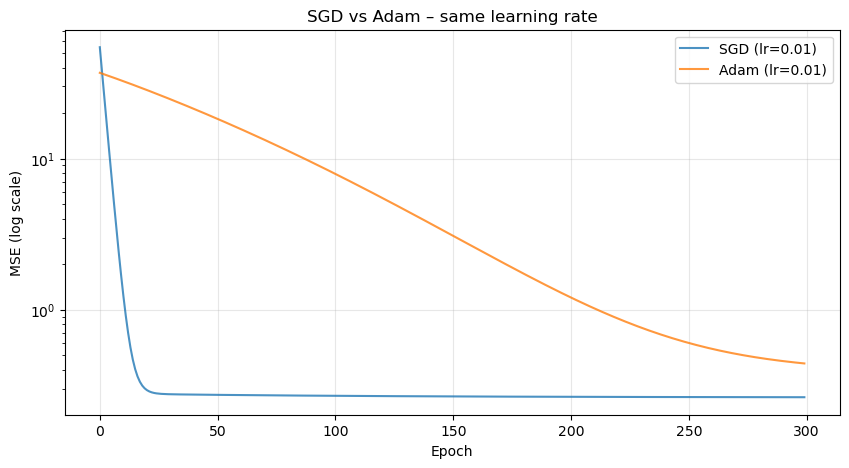

SGD final weight: 2.0194, bias: 0.9552
Adam final weight: 1.7125, bias: 1.6999


In [ ]:
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt

# ----- data -----
torch.manual_seed(0)
X = torch.linspace(0,5,100).reshape(-1,1)
y = 2*X + 1 + torch.randn_like(X)*0.5

# ----- two identical models -----
def get_model_opt(opt_name):
    model = nn.Linear(1,1)
    if opt_name == 'SGD':
        opt = optim.SGD(model.parameters(), lr=0.01)
    else:
        opt = optim.Adam(model.parameters(), lr=0.01)
    return model, opt

model_sgd, opt_sgd = get_model_opt('SGD')
model_adam, opt_adam = get_model_opt('Adam')
loss_fn = nn.MSELoss()

losses_sgd, losses_adam = [], []
epochs = 300

for epoch in range(epochs):
    # SGD
    opt_sgd.zero_grad()
    pred = model_sgd(X)
    loss = loss_fn(pred, y)
    loss.backward()
    opt_sgd.step()
    losses_sgd.append(loss.item())
    
    # Adam
    opt_adam.zero_grad()
    pred = model_adam(X)
    loss = loss_fn(pred, y)
    loss.backward()
    opt_adam.step()
    losses_adam.append(loss.item())

plt.figure(figsize=(10,5))
plt.plot(losses_sgd, label='SGD (lr=0.01)', alpha=0.8)
plt.plot(losses_adam, label='Adam (lr=0.01)', alpha=0.8)
plt.yscale('log')
plt.title('SGD vs Adam – same learning rate')
plt.xlabel('Epoch')
plt.ylabel('MSE (log scale)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'SGD final weight: {model_sgd.weight.item():.4f}, bias: {model_sgd.bias.item():.4f}')
print(f'Adam final weight: {model_adam.weight.item():.4f}, bias: {model_adam.bias.item():.4f}')

## 6. TL;DR

- **Plain GD** → slow, gets stuck.
- **Momentum** → rolls over local minima.
- **Adaptive rates** → big steps on flat areas, tiny steps in ravines.
- **Adam** = momentum + adaptive rates → **default choice** for virtually all deep‑learning code.

---

**You now possess the complete mathematical engine of deep learning!**  